<a href="https://colab.research.google.com/github/MsSaidat25/AI-Engineer-Projects/blob/main/Wholesale_DAtaset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
file_path = "/Wholesale customers data.csv"
data = pd.read_csv(file_path)
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
print(data.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [23]:
outliers = {}

for i in range(data.shape[1]):
    min_t = data[data.columns[i]].mean() \
            - (3 * data[data.columns[i]].std())
    max_t = data[data.columns[i]].mean() \
            + (3 * data[data.columns[i]].std())
    count = 0
    for j in data[data.columns[i]]:
        if j < min_t or j > max_t:
            count += 1
    outliers[data.columns[i]] = [count,data.shape[0]-count]

print(outliers)


{'Channel': [0, 440], 'Region': [0, 440], 'Fresh': [11, 429], 'Milk': [17, 423], 'Grocery': [12, 428], 'Frozen': [16, 424], 'Detergents_Paper': [16, 424], 'Delicassen': [13, 427]}


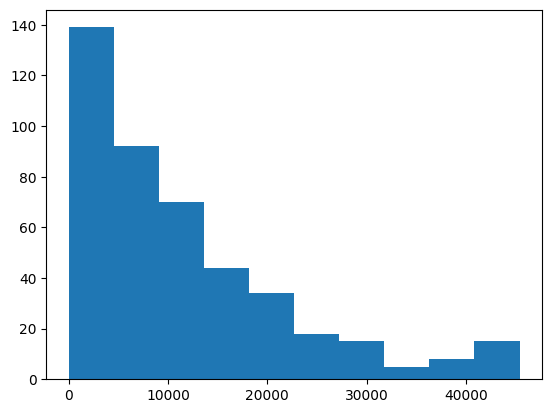

In [24]:
plt.hist(data["Fresh"])
plt.show()

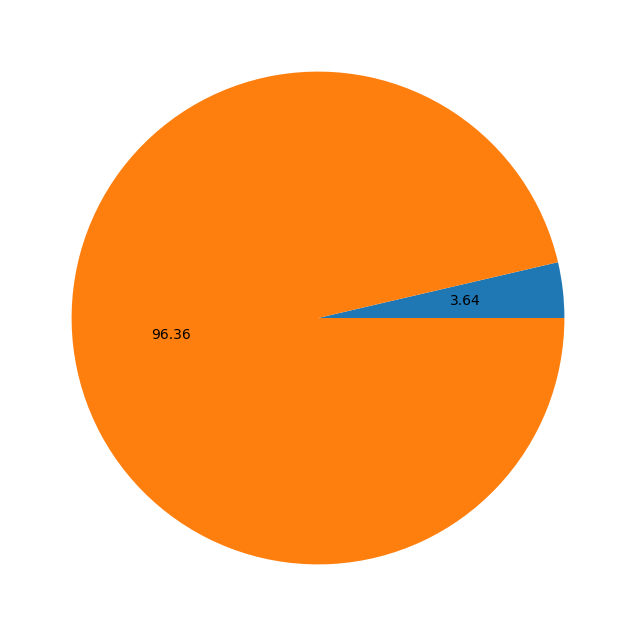

In [25]:
plt.figure(figsize=(8,8))
plt.pie(outliers["Detergents_Paper"],autopct="%.2f")
plt.show()

In [26]:
data_standardized = (data - data.mean())/data.std()
data_standardized.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.447005,0.589997,0.095807,0.807451,0.005647,-0.813013,0.011935,-0.012306
1,1.447005,0.589997,-0.416873,0.836483,0.277664,-0.325349,0.183803,0.315238
2,1.447005,0.589997,-0.481186,0.647584,0.022318,-0.122786,0.245720,3.522001
3,-0.689512,0.589997,0.150254,-0.787447,-0.447037,1.137011,-0.589742,0.324212
4,1.447005,0.589997,1.004415,0.006986,-0.043552,0.352906,-0.237121,2.864551


In [27]:
from sklearn.cluster import KMeans

In [28]:
ideal_k = []
for i in range(1,21):
    est_kmeans = KMeans(n_clusters=i, random_state=0)
    est_kmeans.fit(data)
    ideal_k.append([i,est_kmeans.inertia_])

In [29]:
from sklearn.cluster import KMeans

In [30]:
ideal_k = []
for i in range(1,21):
    est_kmeans = KMeans(n_clusters=i, random_state=0)
    est_kmeans.fit(data_standardized)
    ideal_k.append([i,est_kmeans.inertia_])

ideal_k = np.array(ideal_k)

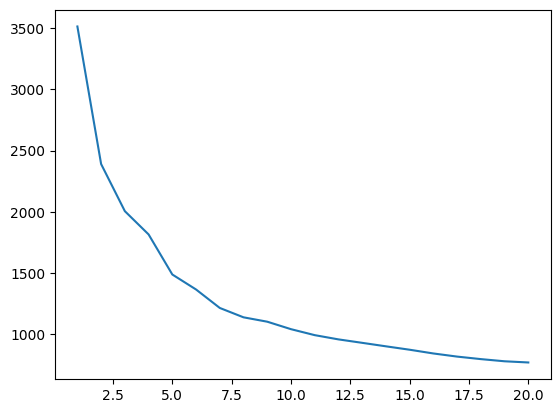

In [31]:
plt.plot(ideal_k[:,0],ideal_k[:,1])
plt.show()

In [34]:
est_kmeans = KMeans(n_clusters=6, random_state = 42)
est_kmeans.fit(data_standardized)
pred_kmeans = est_kmeans.predict(data_standardized)

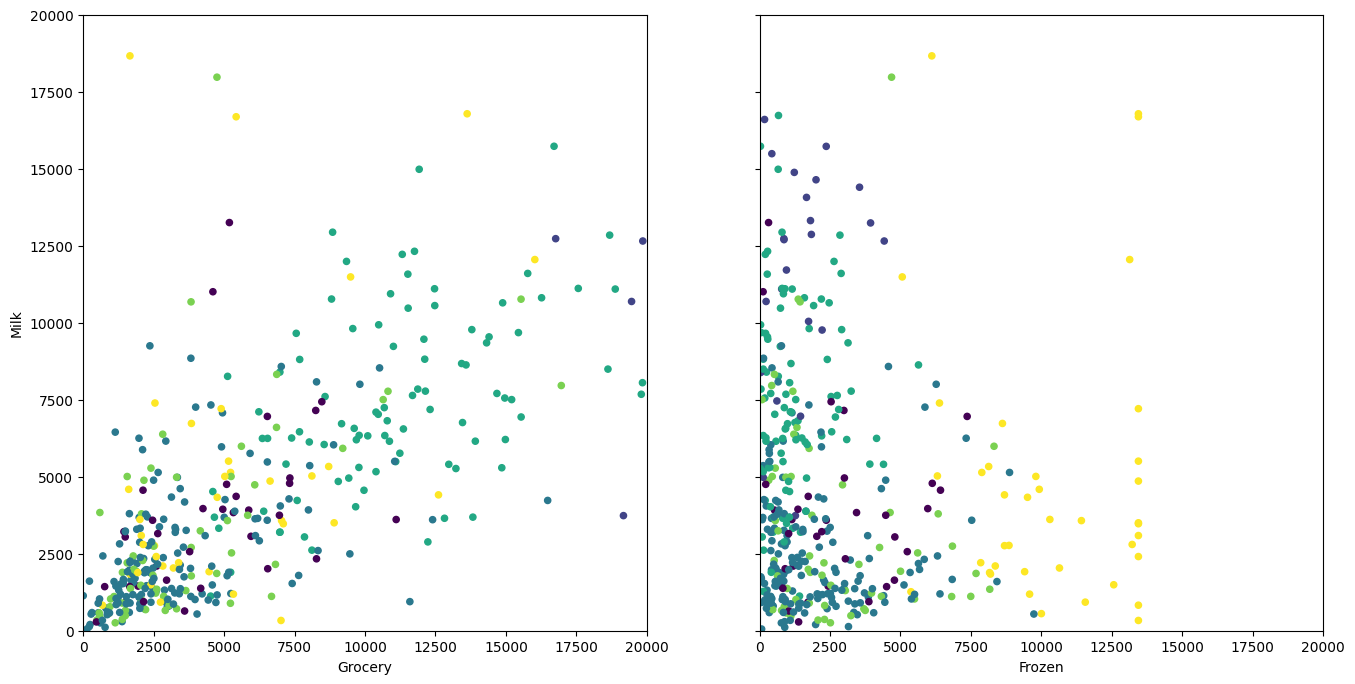

In [33]:
plt.subplots(1, 2, sharex='col', \
             sharey='row', figsize=(16,8))
plt.scatter(data.iloc[:,5], data.iloc[:,3], \
            c=pred_kmeans, s=20)
plt.xlim([0, 20000])
plt.ylim([0, 20000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:,4], data.iloc[:,3], \
            c=pred_kmeans, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()

In [35]:
from sklearn.cluster import MeanShift

In [39]:
est_meanshift = MeanShift(bandwidth=0.8)
est_meanshift.fit(data_standardized)
pred_meanshift = est_meanshift.predict(data_standardized)

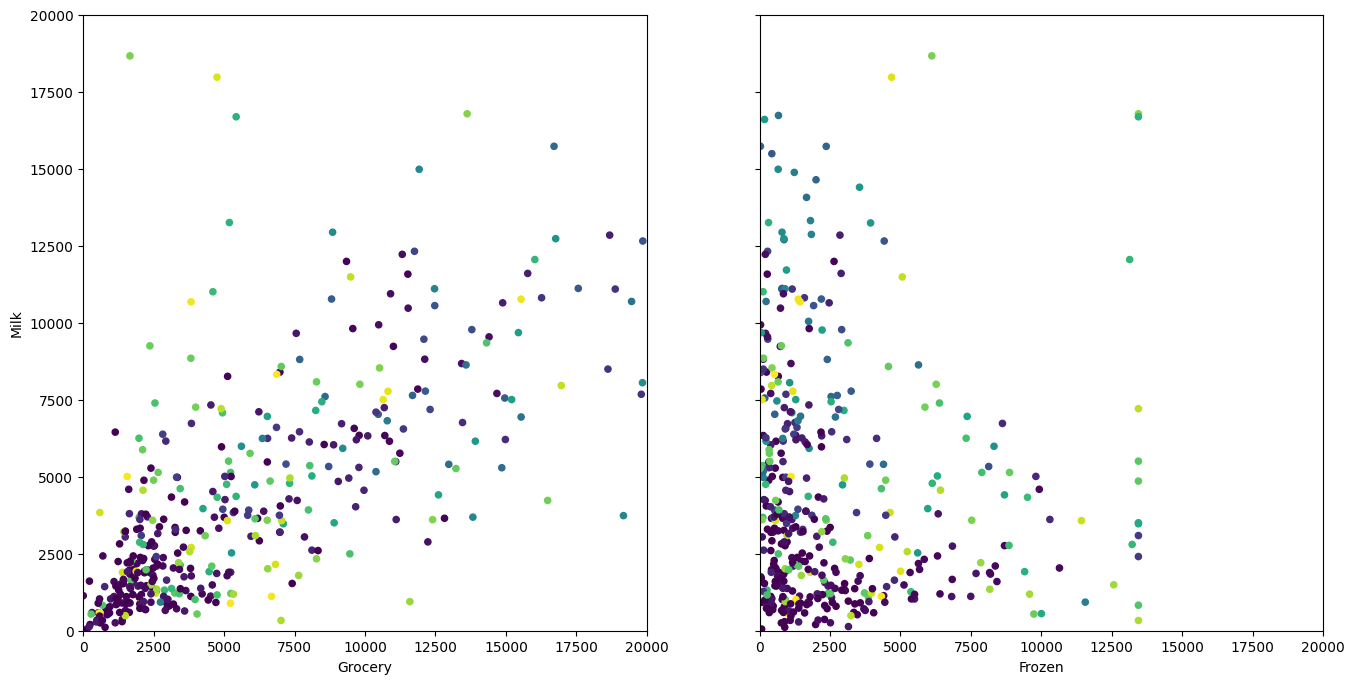

In [40]:
plt.subplots(1, 2, sharex='col', \
             sharey='row', figsize=(16,8))
plt.scatter(data.iloc[:,5], data.iloc[:,3], \
            c=pred_meanshift, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:,4], data.iloc[:,3], \
            c=pred_meanshift, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()

In [41]:
from sklearn.cluster import DBSCAN

In [44]:
est_dbscan = DBSCAN(eps=0.6)
pred_dbscan = est_dbscan.fit_predict(data_standardized)

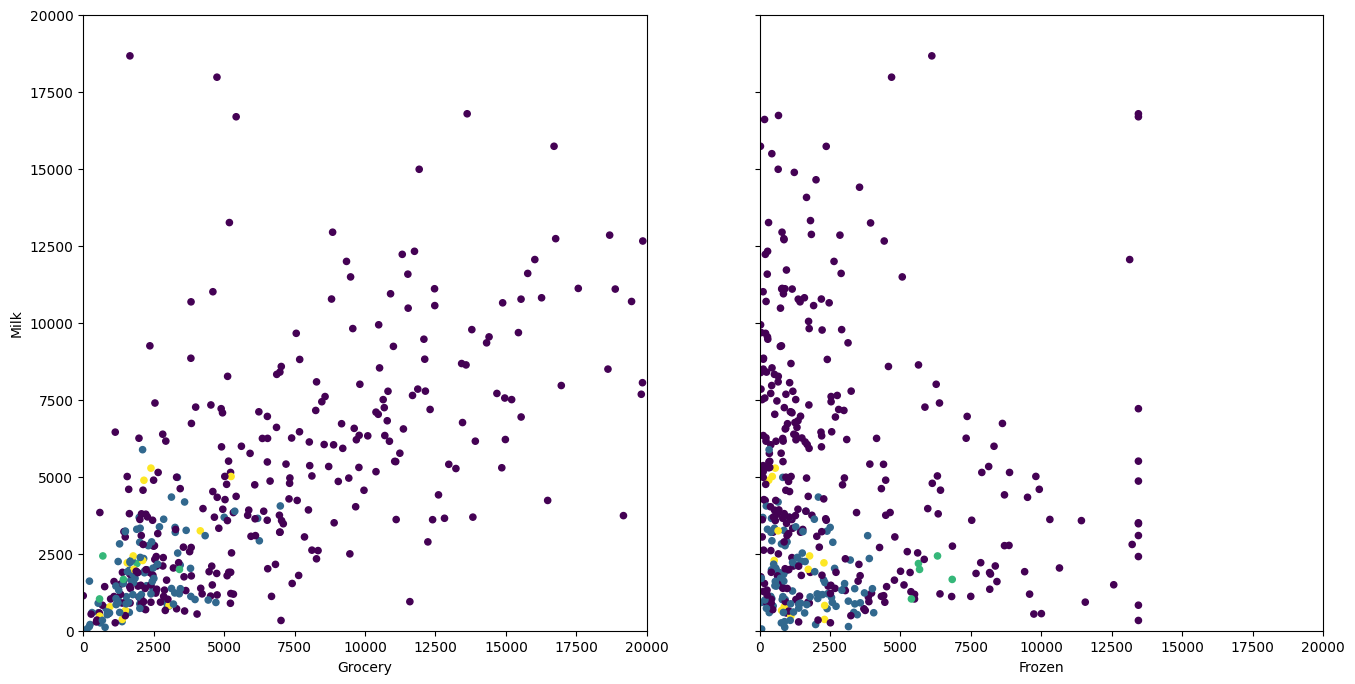

In [45]:
plt.subplots(1, 2, sharex='col', \
             sharey='row', figsize=(16,8))
plt.scatter(data.iloc[:,5], data.iloc[:,3], \
            c=pred_dbscan, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:,4], data.iloc[:,3], \
            c=pred_dbscan, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()